In [44]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Define file path
file_path = r"D:\M3CA_pilot1\hab_M3CA_pilot1.csv"

# Load the CSV file 
df = pd.read_csv(file_path)

# Extract ROI columns
left_roi = df["Left ROI : time investigating (s)"]
right_roi = df["Right ROI : time investigating (s)"]


In [45]:
# Compute differences
diff = left_roi - right_roi

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(diff)
print(f"Shapiro-Wilk normality test: W = {shapiro_stat:.3f}, p = {shapiro_p:.3f}")

# Determine which test to use
if shapiro_p > 0.05:
    print("Data is normally distributed. Using paired t-test.")
    stat, p_value = stats.ttest_rel(left_roi, right_roi)
    test_name = "Paired t-test"
else:
    print("Data is NOT normally distributed. Using Wilcoxon signed-rank test.")
    stat, p_value = stats.wilcoxon(left_roi, right_roi)
    test_name = "Wilcoxon signed-rank test"

print(f"{test_name}: statistic = {stat:.3f}, p-value = {p_value:.3f}")


Shapiro-Wilk normality test: W = 0.944, p = 0.399
Data is normally distributed. Using paired t-test.
Paired t-test: statistic = 0.249, p-value = 0.807


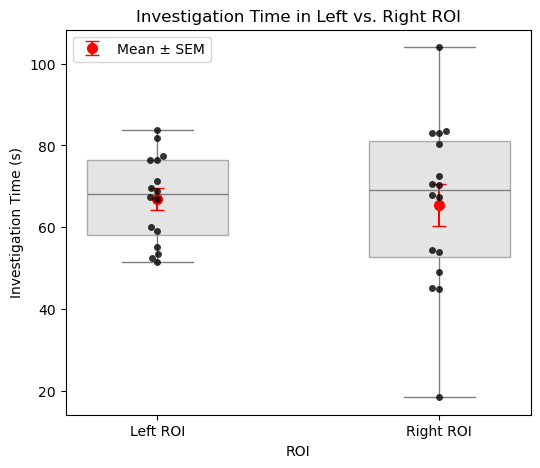

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape data for plotting
df_plot = pd.melt(df, id_vars=["Animal"], 
                  value_vars=["Left ROI : time investigating (s)", "Right ROI : time investigating (s)"],
                  var_name="ROI", value_name="Investigation Time (s)")

# Standardize ROI labels
df_plot["ROI"] = df_plot["ROI"].replace({
    "Left ROI : time investigating (s)": "Left ROI",
    "Right ROI : time investigating (s)": "Right ROI"
})

# Set up figure
plt.figure(figsize=(6, 5))

# Box plot
sns.boxplot(x="ROI", y="Investigation Time (s)", data=df_plot, width=0.5, showfliers=False, 
            boxprops=dict(alpha=0.6), color="lightgray")

# Swarm plot (individual data points)
sns.swarmplot(x="ROI", y="Investigation Time (s)", data=df_plot, color="black", alpha=0.8)

# Connect paired data points for each subject
for animal in df["Animal"].unique():
    subject_data = df_plot[df_plot["Animal"] == animal]
    if len(subject_data) == 2:  # Ensure both ROIs exist
        plt.plot(subject_data["ROI"], subject_data["Investigation Time (s)"], 
                 marker="o", linestyle="-", color="gray", alpha=0.6, linewidth=1)

# Compute means and SEM
means = df_plot.groupby("ROI")["Investigation Time (s)"].mean()
sems = df_plot.groupby("ROI")["Investigation Time (s)"].sem()

# Add error bars for SEM
plt.errorbar(x=["Left ROI", "Right ROI"], y=means, yerr=sems, fmt="o", 
             color="red", capsize=5, markersize=7, label="Mean ± SEM")

# Formatting
plt.xlabel("ROI")
plt.ylabel("Investigation Time (s)")
plt.title("Investigation Time in Left vs. Right ROI")
plt.legend()
plt.grid(False)
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\1426348067.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\1426348067.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\1426348067.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Tem

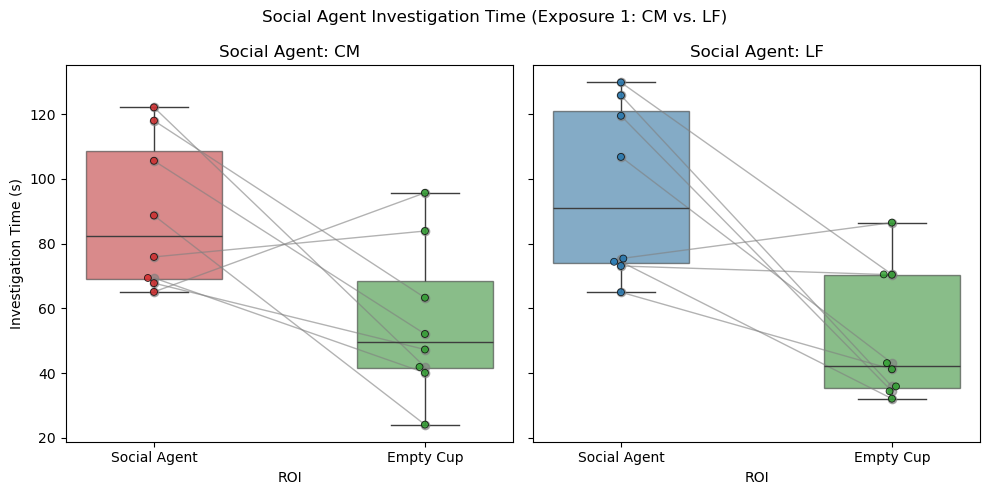

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load DataFrame
file_path = r"D:\M3CA_pilot1\exposure1_M3CA_pilot1.csv"
df = pd.read_csv(file_path)

# Reshape data for plotting
df_plot = pd.melt(df, id_vars=["Animal", "Treatment"], 
                  value_vars=["Social agent ROI : time investigating (s)", "Empty cup ROI : time investigating (s)"],
                  var_name="ROI", value_name="Investigation Time (s)")

# Rename for readability
df_plot["ROI"] = df_plot["ROI"].replace({
    "Social agent ROI : time investigating (s)": "Social Agent",
    "Empty cup ROI : time investigating (s)": "Empty Cup"
})

# Define color palette for CM and LF
palette_cm = {"Social Agent": "#d62728", "Empty Cup": "#2ca02c"}  # CM: Red, Empty Cup: Green
palette_lf = {"Social Agent": "#1f77b4", "Empty Cup": "#2ca02c"}  # LF: Blue, Empty Cup: Green

# Create separate plots for each social agent condition
treatments = df["Treatment"].unique()
fig, axes = plt.subplots(1, len(treatments), figsize=(10, 5), sharey=True)

for ax, treatment in zip(axes, treatments):
    subset = df_plot[df_plot["Treatment"] == treatment]

    # Choose correct color scheme based on treatment
    palette = palette_cm if "CM" in treatment else palette_lf  

    # Box plot
    sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax, 
                showfliers=False, width=0.5, boxprops=dict(alpha=0.6), palette=palette)

    # Scatter plot of individual data points
    sns.swarmplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax, 
                  dodge=False, alpha=0.8, edgecolor="black", linewidth=0.6, palette=palette)

    # Connect individual subjects with lines
    for animal in df["Animal"].unique():
        subject_data = subset[subset["Animal"] == animal]
        if len(subject_data) == 2:  # Ensure both conditions exist
            ax.plot(subject_data["ROI"], subject_data["Investigation Time (s)"], 
                    marker="o", linestyle="-", color="gray", alpha=0.6, linewidth=1)

    # Formatting
    ax.set_title(f"Social Agent: {treatment}")  # Updated title format
    ax.set_xlabel("ROI")
    ax.set_ylabel("Investigation Time (s)")

plt.suptitle("Social Agent Investigation Time (Exposure 1: CM vs. LF)")
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\4067241556.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\4067241556.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\4067241556.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax,
C:\Users\sjs93\AppData\Local\Tem

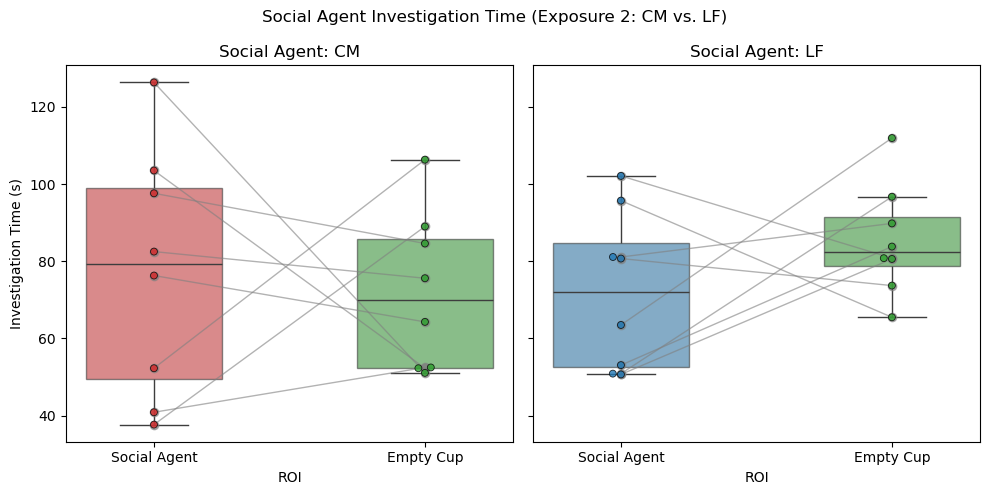

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load DataFrame
file_path = r"D:\M3CA_pilot1\exposure2_M3CA_pilot1.csv"
df = pd.read_csv(file_path)

# Reshape data for plotting
df_plot = pd.melt(df, id_vars=["Animal", "Treatment"], 
                  value_vars=["Social agent ROI : time investigating (s)", "Empty cup ROI : time investigating (s)"],
                  var_name="ROI", value_name="Investigation Time (s)")

# Rename for readability
df_plot["ROI"] = df_plot["ROI"].replace({
    "Social agent ROI : time investigating (s)": "Social Agent",
    "Empty cup ROI : time investigating (s)": "Empty Cup"
})

# Define color palette for CM and LF
palette_cm = {"Social Agent": "#d62728", "Empty Cup": "#2ca02c"}  # CM: Red, Empty Cup: Green
palette_lf = {"Social Agent": "#1f77b4", "Empty Cup": "#2ca02c"}  # LF: Blue, Empty Cup: Green

# Create separate plots for each social agent condition
treatments = df["Treatment"].unique()
fig, axes = plt.subplots(1, len(treatments), figsize=(10, 5), sharey=True)

for ax, treatment in zip(axes, treatments):
    subset = df_plot[df_plot["Treatment"] == treatment]

    # Choose correct color scheme based on treatment
    palette = palette_cm if "CM" in treatment else palette_lf  

    # Box plot
    sns.boxplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax, 
                showfliers=False, width=0.5, boxprops=dict(alpha=0.6), palette=palette)

    # Scatter plot of individual data points
    sns.swarmplot(x="ROI", y="Investigation Time (s)", data=subset, ax=ax, 
                  dodge=False, alpha=0.8, edgecolor="black", linewidth=0.6, palette=palette)

    # Connect individual subjects with lines
    for animal in df["Animal"].unique():
        subject_data = subset[subset["Animal"] == animal]
        if len(subject_data) == 2:  # Ensure both conditions exist
            ax.plot(subject_data["ROI"], subject_data["Investigation Time (s)"], 
                    marker="o", linestyle="-", color="gray", alpha=0.6, linewidth=1)

    # Formatting
    ax.set_title(f"Social Agent: {treatment}")  # Updated title format
    ax.set_xlabel("ROI")
    ax.set_ylabel("Investigation Time (s)")

plt.suptitle("Social Agent Investigation Time (Exposure 2: CM vs. LF)")
plt.tight_layout()
plt.show()




Paired t-test: t = 0.660, p = 0.519


C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\1321106272.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Social Agent", y="Investigation Time (s)", data=df_plot,
C:\Users\sjs93\AppData\Local\Temp\ipykernel_53512\1321106272.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Social Agent", y="Investigation Time (s)", data=df_plot,


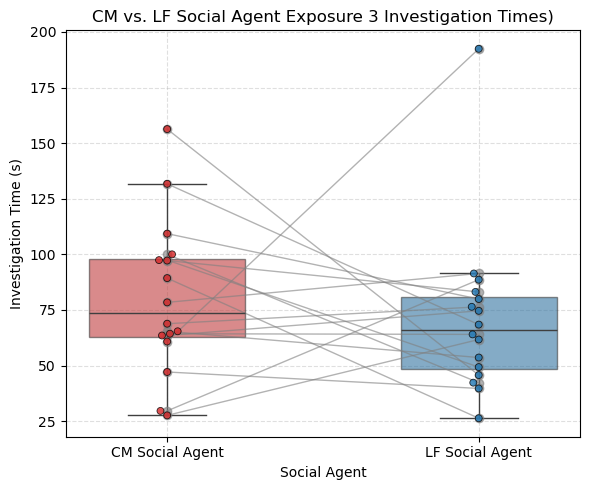

In [49]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load DataFrame
file_path = r"D:\M3CA_pilot1\exposure3_M3CA_pilot1.csv"
df = pd.read_csv(file_path)

# Extract paired data
cm_times = df["Cm social agent ROI : time investigating (s)"]
lf_times = df["Lf social agent ROI : time investigating (s)"]

# Paired t-test
t_stat, p_value = stats.ttest_rel(cm_times, lf_times)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3f}")

# Reshape data for plotting
df_plot = pd.melt(df, id_vars=["Animal"], 
                  value_vars=["Cm social agent ROI : time investigating (s)", "Lf social agent ROI : time investigating (s)"],
                  var_name="Social Agent", value_name="Investigation Time (s)")

# Rename for readability
df_plot["Social Agent"] = df_plot["Social Agent"].replace({
    "Cm social agent ROI : time investigating (s)": "CM Social Agent",
    "Lf social agent ROI : time investigating (s)": "LF Social Agent"
})

# Define color palette
palette = {"CM Social Agent": "#d62728", "LF Social Agent": "#1f77b4"}  # Red and Blue

# Create figure
plt.figure(figsize=(6, 5))

# Box plot
sns.boxplot(x="Social Agent", y="Investigation Time (s)", data=df_plot,
            showfliers=False, width=0.5, boxprops=dict(alpha=0.6), palette=palette)

# Scatter plot (individual data points)
sns.swarmplot(x="Social Agent", y="Investigation Time (s)", data=df_plot,
              edgecolor="black", linewidth=0.6, alpha=0.8, palette=palette)

# Connect individual subjects with lines
for i, animal in enumerate(df["Animal"]):
    cm_value = cm_times.iloc[i]
    lf_value = lf_times.iloc[i]
    plt.plot(["CM Social Agent", "LF Social Agent"], [cm_value, lf_value],
             marker="o", color="gray", alpha=0.6, linewidth=1)


# Formatting
plt.xlabel("Social Agent")
plt.ylabel("Investigation Time (s)")
plt.title("CM vs. LF Social Agent Exposure 3 Investigation Times)")
plt.grid(True, linestyle="--", alpha=0.4)

# Show plot
plt.tight_layout()
plt.show()